Circuit:

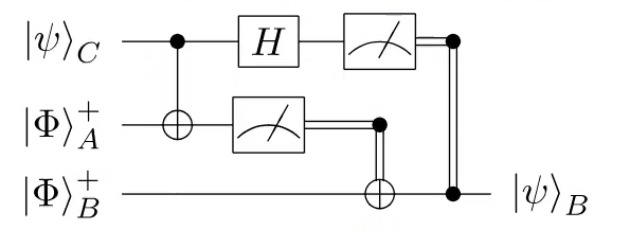

In [44]:
# Example 1 -> Pegar um qibit, emaranhar (state C), medir na base de "alice" e mandar para o Bob (See B84 protocol)

# Cria o estado C (emaranhando) que é enviado com o estado Alice (A) e medido em Bob (B)

#First step - Install dependencies
!pip install -q qiskit qiskit-aer matplotlib
!pip install -q pylatexenc
%matplotlib inline

In [45]:
%pip install pylatexenc

Note: you may need to restart the kernel to use updated packages.


In [46]:
from qiskit import QuantumCircuit #Build Quantum circuit
from qiskit import QuantumRegister #Register bits
from qiskit import ClassicalRegister #Register classical bits
from qiskit import transpile #Enable link with simulation (if necessary)
from qiskit_aer import AerSimulator #Local Simulator
from qiskit.visualization import plot_histogram #Plot histograms
import matplotlib.pyplot as plt
from qiskit.result import marginal_counts #See only qibits

In [47]:
a = 1 # Constant Alice
b = 2 # Constant Bob
c = 0 # Constant Data to send

In [48]:
# Create classic and quantum registers
qubits = QuantumRegister(3, "q") # 3 qubits
bits = ClassicalRegister(3, "m") # 3 classical bit to caught measure results
quantum_circuit = QuantumCircuit(qubits, bits) # Create the quantum circuit


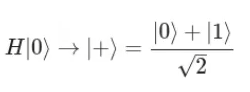

In [49]:
# Prepare Bell State for C
quantum_circuit.h(qubits[c]) # User Hadamard in C to create superposition in C

In [50]:
#Emaranhamento entre Alice e Bob - Isso acontece, porque suponhamos que Alice quer mandar uma mensagem para o Bob, então eles combinam um estado emaranhado, que eles criam juntos, e Bob futuramente usa esse estado para reconstruir a informação quântica teleportada
quantum_circuit.h(qubits[a])
quantum_circuit.cx(qubits[a], qubits[b]) # A porta Cnot causa o emaranhamento


In [51]:
# Circuit to send information
quantum_circuit.cx(qubits[c], qubits[a])
quantum_circuit.h(qubits[c])

In [52]:
# Measure the circuit
quantum_circuit.measure(qubits[c], bits[0]) #Aqui Alice mede o qubit c e salva em m[0]
quantum_circuit.measure(qubits[a], bits[1]) #Alice mede em A e salva em m[1]

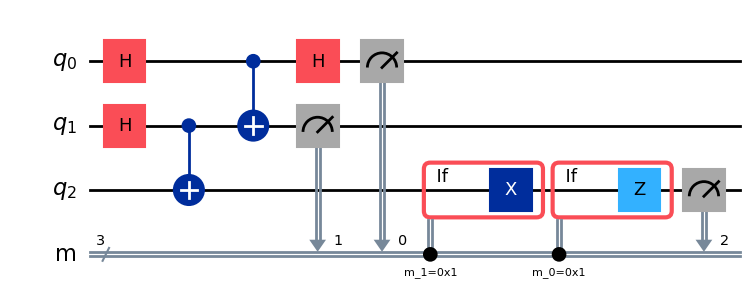

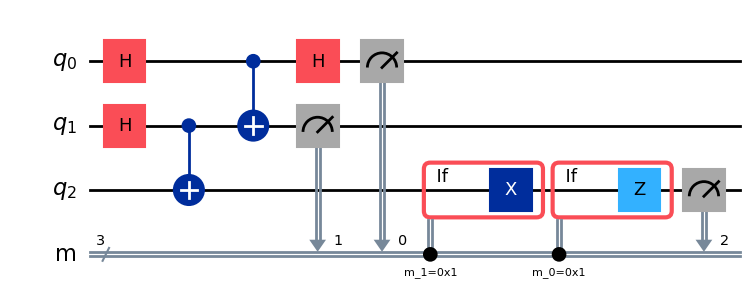

In [53]:
# Fixing apply per Bob
with quantum_circuit.if_test((bits[1], 1)):
    quantum_circuit.x(qubits[b])
with quantum_circuit.if_test((bits[0],1)):
    quantum_circuit.z(qubits[b])


quantum_circuit.measure(qubits[b], bits[2])
quantum_circuit.draw("mpl")

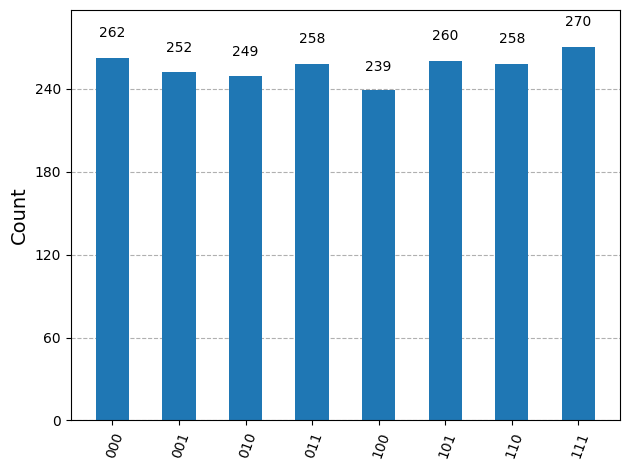

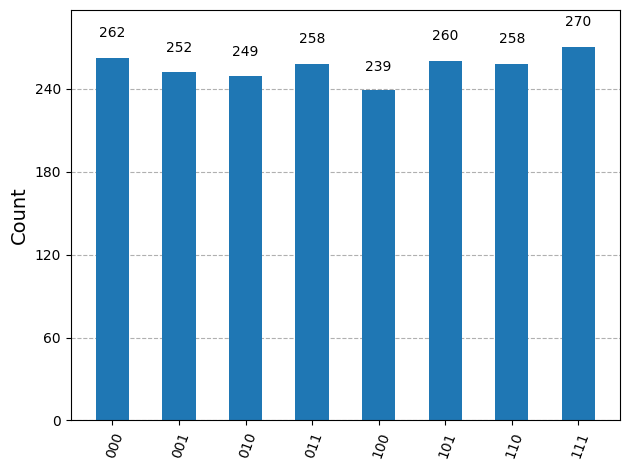

In [54]:
# Simulation with Histogram
simulator = AerSimulator()
transpile_quantum_circuit = transpile(quantum_circuit, simulator)

result = simulator.run(transpile_quantum_circuit, shots = 2048).result() # Shots is quantite tests for measure in a quantum computer
counts = result.get_counts()

plot_histogram(counts)


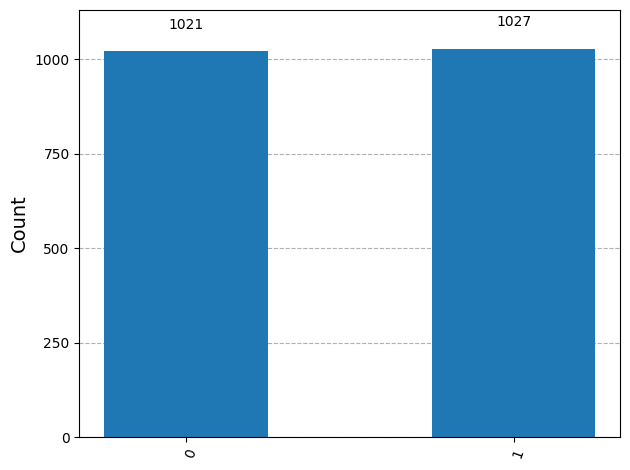

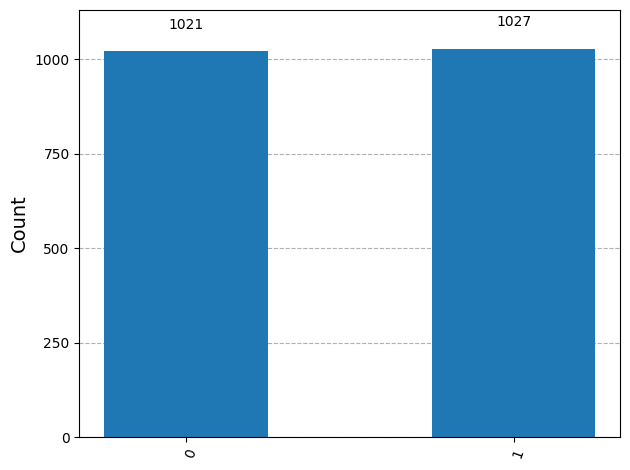

In [55]:
''#Filter histogram

counts_bob = marginal_counts(counts, [b])
plot_histogram(counts_bob)